<a href="https://colab.research.google.com/github/seitenovagulnara-code/document-categorization/blob/main/notebooks/EDA_and_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Document Categorization & Tagging — EDA & Training

Ноутбук воспроизводит модель: загрузка данных, EDA, бейзлайн, дообучение DistilBERT, оценка.

**Тяжёлое обучение (этап 5) запускать в Google Colab с GPU.**

Датасет: XGLUE-NC (новости, 10 категорий, en + ru).

## Этап 0 — Настройка окружения

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
%cd /content
!pwd

/content
/content


In [ ]:
!rm -rf document-categorization

In [ ]:
!git clone https://github.com/seitenovagulnara-code/document-categorization.git
%cd /content/document-categorization
!ls

fatal: destination path 'document-categorization' already exists and is not an empty directory.
/content/document-categorization
app  data  models  notebooks  README.md  reports  requirements.txt  utils


In [ ]:
!grep -n "lang" utils/text_preprocessing.py

6:  - detect_language()    — определение языка (нужно тегировщику на этапе 7).
44:def detect_language(text: str) -> str:
49:    from langdetect import detect  # импорт внутри — модуль грузится без langdetect
56:def classic_preprocess(text: str, lang: str = None) -> str:
62:    полезный сигнал. Параметр lang оставлен для совместимости сигнатуры.


## Этап 1 — Загрузка данных (XGLUE-NC)

In [ ]:
import pandas as pd
from datasets import load_dataset

REPO = "mteb/amazon_massive_scenario"
SCENARIO = ["alarm","audio","calendar","cooking","datetime","email","general",
            "iot","lists","music","news","play","qa","recommendation",
            "social","takeaway","transport","weather"]
idx = {n:i for i,n in enumerate(SCENARIO)}

def load_massive(languages=("en","ru"), limit_per_split=None):
    frames=[]
    for lang in languages:
        ds = load_dataset(REPO, lang)          # parquet, без скриптов
        for split in ds.keys():
            raw = ds[split].to_pandas()
            if limit_per_split: raw = raw.head(limit_per_split)
            tcol = "text" if "text" in raw.columns else "utt"
            if "label_text" in raw.columns:   name = raw["label_text"].astype(str)
            elif raw["label"].dtype == object: name = raw["label"].astype(str)
            else:                              name = raw["label"].astype(int).map(lambda i: SCENARIO[i])
            frames.append(pd.DataFrame({
                "text": raw[tcol].fillna("").astype(str).str.strip(),
                "label": name.map(lambda n: idx.get(n,-1)),
                "label_name": name, "language": lang, "split": split}))
    return pd.concat(frames, ignore_index=True)

try:
    df = load_massive(limit_per_split=200)
    print(df.groupby(["language","split"]).size())
    print(df.iloc[0]["text"], "|", df.iloc[0]["label_name"])
except Exception as e:
    from datasets import get_dataset_config_names
    print("Ошибка:", e)
    print("Доступные конфиги:", get_dataset_config_names(REPO))

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

language  split     
en        test          200
          train         200
          validation    200
ru        test          200
          train         200
          validation    200
dtype: int64
wake me up at nine am on friday | alarm


In [ ]:
df = load_massive()   # без limit_per_split — всё
print("Всего:", len(df))
print(df["label_name"].value_counts())


Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Всего: 33042
label_name
calendar          4740
play              4048
qa                3370
email             2762
iot               2214
general           1926
weather           1710
transport         1610
lists             1586
news              1418
recommendation    1192
datetime          1156
social            1130
alarm             1100
music              938
audio              774
takeaway           716
cooking            652
Name: count, dtype: int64


## Этап 2 — EDA + базовая очистка
Баланс классов, длины текстов, языки; общая чистка.

Документов по категориям:
 language          en    ru
label_name                
calendar        2370  2370
play            2024  2024
qa              1685  1685
email           1381  1381
iot             1107  1107
general          963   963
weather          855   855
transport        805   805
lists            793   793
news             709   709
recommendation   596   596
datetime         578   578
social           565   565
alarm            550   550
music            469   469
audio            387   387
takeaway         358   358
cooking          326   326


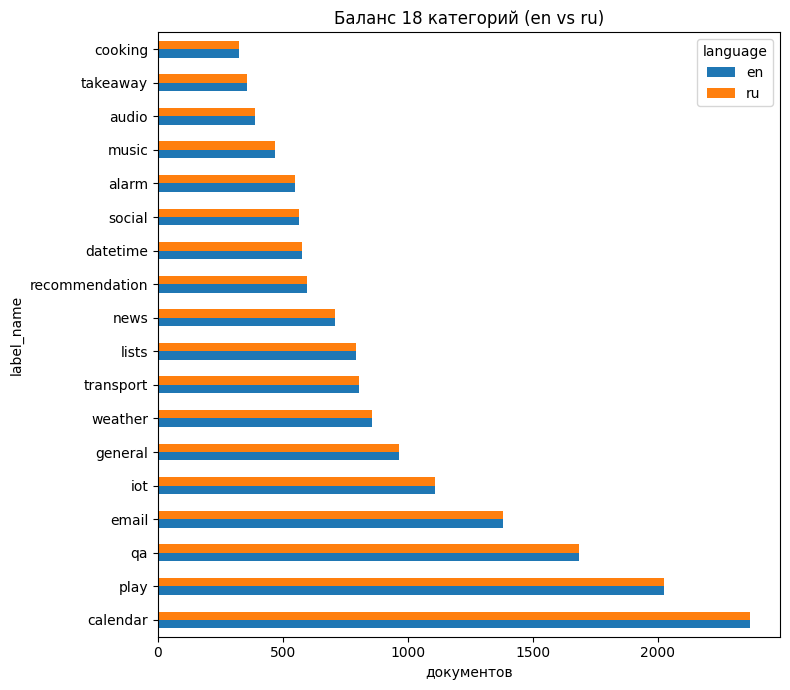


Длина текста (слов):
mean     6.380607
50%      6.000000
max     61.000000
Name: n_words, dtype: float64


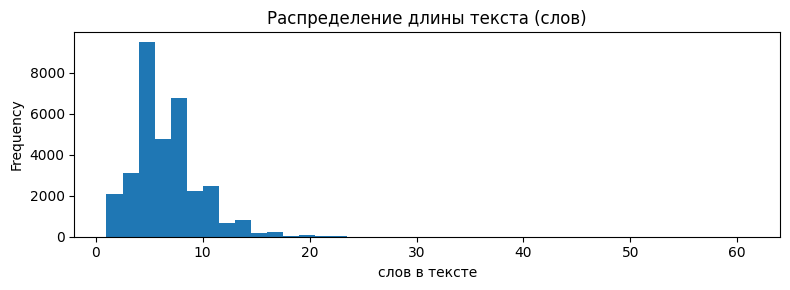


Пустых текстов: 0


In [ ]:
import matplotlib.pyplot as plt

# --- 1. Баланс категорий (сравним en и ru) ---
counts = df.groupby(["label_name","language"]).size().unstack(fill_value=0)
counts = counts.sort_values("en", ascending=False)
print("Документов по категориям:\n", counts)

counts.plot(kind="barh", figsize=(8,7))
plt.title("Баланс 18 категорий (en vs ru)")
plt.xlabel("документов"); plt.tight_layout(); plt.show()

# --- 2. Длина текстов (в словах) ---
df["n_words"] = df["text"].str.split().str.len()
print("\nДлина текста (слов):")
print(df["n_words"].describe()[["mean","50%","max"]])

df["n_words"].plot(kind="hist", bins=40, figsize=(8,3))
plt.title("Распределение длины текста (слов)")
plt.xlabel("слов в тексте"); plt.tight_layout(); plt.show()

# --- 3. Пустые/битые тексты ---
print("\nПустых текстов:", (df["n_words"]==0).sum())

In [ ]:
# по паре примеров из разных категорий
for cat in ["calendar", "news", "weather", "cooking"]:
    print(f"\n=== {cat} ===")
    sample = df[(df.language=="en") & (df.label_name==cat)]["text"].head(2).tolist()
    for t in sample:
        print(" •", t)


=== calendar ===
 • check when the show starts
 • please tell me current events for the day

=== news ===
 • what's happening in football today
 • tell me b. b. c. news

=== weather ===
 • is it raining
 • is it going to rain

=== cooking ===
 • what to cook for lunch
 • how long should i boil the eggs


In [ ]:
!git pull

Already up to date.


## Этап 4 — Бейзлайн: TF-IDF + LogisticRegression

In [ ]:
from utils.data_loader import get_train_val_test
from models.text_classifier import train_baseline, evaluate

splits = get_train_val_test()          # загрузит данные и разложит
model = train_baseline(splits)         # обучение (несколько секунд на CPU)

metrics = evaluate(model, splits, report=True)   # метрики + отчёт по классам
print(metrics)

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]


=== en ===
                precision    recall  f1-score   support

         alarm       0.98      0.94      0.96        96
         audio       0.98      0.74      0.84        62
      calendar       0.83      0.95      0.89       402
       cooking       0.96      0.67      0.79        72
      datetime       0.89      0.88      0.89       103
         email       0.94      0.93      0.94       271
       general       0.67      0.50      0.57       189
           iot       0.97      0.95      0.96       220
         lists       0.92      0.86      0.89       142
         music       0.93      0.70      0.80        81
          news       0.87      0.76      0.81       124
          play       0.91      0.95      0.93       387
            qa       0.66      0.91      0.76       288
recommendation       0.78      0.74      0.76        94
        social       0.98      0.80      0.88       106
      takeaway       0.96      0.77      0.85        57
     transport       0.91      0.88

In [ ]:
model.save()   # -> models/checkpoints/baseline_tfidf_logreg.joblib

PosixPath('/content/document-categorization/models/checkpoints/baseline_tfidf_logreg.joblib')

## Этап 5 — Дообучение DistilBERT (GPU / Colab)

In [1]:
%cd /content

/content


In [2]:
!rm -rf document-categorization

In [3]:
!git clone https://github.com/seitenovagulnara-code/document-categorization.git

Cloning into 'document-categorization'...
remote: Enumerating objects: 65, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 65 (delta 26), reused 48 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (65/65), 2.64 MiB | 34.20 MiB/s, done.
Resolving deltas: 100% (26/26), done.


In [4]:
%cd /content/document-categorization

/content/document-categorization


In [5]:
!pip install -q transformers datasets
import torch
print("GPU доступен:", torch.cuda.is_available())   # должно быть True

GPU доступен: True


In [6]:
from utils.data_loader import get_train_val_test
from utils.transfer_learning import train, evaluate_transformer

splits = get_train_val_test()
model, tokenizer, trainer = train(splits)

README.md:   0%|          | 0.00/19.6k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

train/en.json.gz: reconstructing file:   0%|          |  0.00B /  180kB            

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [7]:
bert = evaluate_transformer(model, tokenizer, splits)
print("BERT:", bert)
print("Бейзлайн был: overall acc 0.850, f1 0.841")

BERT: {'en': {'accuracy': 0.9055, 'f1_macro': 0.8984, 'n': 2974}, 'ru': {'accuracy': 0.8904, 'f1_macro': 0.8822, 'n': 2974}, 'overall': {'accuracy': 0.8979, 'f1_macro': 0.8903, 'n': 5948}}
Бейзлайн был: overall acc 0.850, f1 0.841


In [8]:
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p "/content/drive/MyDrive/dct_model"
!cp -r models/checkpoints/* "/content/drive/MyDrive/dct_model/"
!ls "/content/drive/MyDrive/dct_model"

Mounted at /content/drive
baseline_tfidf_logreg.joblib  config.json	     tokenizer.json
checkpoint-2880		      model.safetensors      training_args.bin
checkpoint-3600		      tokenizer_config.json  training_history.csv


## Этап 6 — Оценка и сравнение с бейзлайном
accuracy, F1-macro, матрица ошибок, per-language, обгон бейзлайна ≥5%.

In [9]:
import json
report = {
    "classification_accuracy": bert["overall"]["accuracy"],
    "f1_score_macro": bert["overall"]["f1_macro"],
    "processing_speed_docs_per_sec": None,   # измерим на этапе 8
    "languages_supported": ["en", "ru"],
    "per_language_accuracy": {"en": bert["en"]["accuracy"], "ru": bert["ru"]["accuracy"]},
}
with open("reports/performance_metrics.json", "w") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)
print(open("reports/performance_metrics.json").read())

{
  "classification_accuracy": 0.8979,
  "f1_score_macro": 0.8903,
  "processing_speed_docs_per_sec": null,
  "languages_supported": [
    "en",
    "ru"
  ],
  "per_language_accuracy": {
    "en": 0.9055,
    "ru": 0.8904
  }
}
